# Import Libaries

In [245]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches #for waffle charts

In [247]:
mpl.style.use('ggplot') #optional - for `ggplot`-like style

#import primary modules:
import numpy as np #Useful formany scientific computing in Python
import pandas as pd #primary data structure library
from PIL import Image #converting images into arrays

#import seaborn and wordcloud
!pip install seaborn wordcloud

#import seaborn
import seaborn as sns

#import wordcloud
import wordcloud

#check for latest version of Matplotlib and seaborn
print ('Matplotlib cersion: ', mpl.__version__)
print('Seaborn version: ', sns.__version__)
print('WordCloud version: ', wordcloud.__version__)

Matplotlib cersion:  3.9.2
Seaborn version:  0.13.2
WordCloud version:  1.9.4


# Fetching Data

toolkits: this heavily relies on __pandas__ and __Numpy__ for *data wrangling*, *analysis* and *visualization*. The primary plotting library we will explore is __Matplotlib__<br>
Dataset: Immigration to Canda from 1990 to 2013 - [International migration flows to and from selected countries - The 2015 revision](https://www.un.org/development/desa/pd/data/international-migration-flows) from United Nation's website 
<br>
The dataset contains annual data on the flows of international migrants as recorded by the countries of destinaiton. The data presents both inflows and outflows according to the place of birth, citizenship or place of previous/next residence both for foreigners and nationals.
<br>
We wil focus on the Canadian immigration data and use the *already cleaned dataset*<br>
You can refer to the data pre-processing where this dataset is cleaned for quick regresh  on your pandas skills [Data pre-processing with Pandas](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/v4/DV0101EN-Exercise-Dataset-Preprocessing-Exploring-with-Pandas.ipynb)

In [66]:
#Download the Canadian Immigration dataset and read it into a pandas dataframe

df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')
print('Data read into a pandas dataframe')

Data read into a pandas dataframe


In [68]:
#look at the first 5 rows
df_can.head(5)

,Country,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1223,856,702,560,716,561,539,620,603,15699
2,Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
3,American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
4,Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,...,0,1,1,0,0,0,0,1,1,15


In [70]:
#print the dimensions ofthe `dataframe`
print(df_can.shape)

(195, 39)


In [72]:
#set Coutnry as the index
df_can.set_index('Country', inplace = True)

# Waffle Charts

a `Waffle chart` is an interesting way visualization that is normally created to display progress toward goals.
<br> it is commonly an effectibe option when you are trying to add interesting visualization features to a visual that consists mainly of cells such as an Excel dashboard

Let's revisit the previous case study in Denmark, Norway and Sweden

In [74]:
#Create a new dataframe for these 3 countries
df_dsn = df_can.loc[['Denmark', 'Norway', 'Sweden']]

df_dsn

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Denmark,Europe,Northern Europe,Developed regions,272,293,299,106,93,73,93,...,62,101,97,108,81,92,93,94,81,3901
Norway,Europe,Northern Europe,Developed regions,116,77,106,51,31,54,56,...,57,53,73,66,75,46,49,53,59,2327
Sweden,Europe,Northern Europe,Developed regions,281,308,222,176,128,158,187,...,205,139,193,165,167,159,134,140,140,5866


Unlike in *R*, `Waffle charts` are not built into any of the Python visualization libraries. Therefore, we must create them from scratch

**step 1.** Determine the proportion of each category with respect to the total

In [76]:
#compute the proportion of each category with respect to the total
total_values = df_dsn['Total'].sum()
category_proportions = df_dsn['Total']/total_values

#print the proportions
pd.DataFrame({"Categorical Proportion": category_proportions})

,Categorical Proportion
Country,
Denmark,0.322557
Norway,0.192409
Sweden,0.485034


**Step 2.** Define the overall size of the `waffle` chart

In [78]:
width = 40 #width of chart
height = 10 #height of chart

total_num_tiles = width * height #total number of tiles

print(f'total number of tiles is {total_num_tiles}.')

total number of tiles is 400.


**Step 3.** Use the proportion of each category to determine it's respective number of tiles

In [80]:
#compute the number of tiles in each category

tiles_per_category = (category_proportions * total_num_tiles).round().astype(int)

#print out number of tiles per category
pd.DataFrame({"number of tiles": tiles_per_category})

,number of tiles
Country,
Denmark,129
Norway,77
Sweden,194


Based on the calculated proportions, Denmark will occupy 129 tiles of the `waffle` chart, Norway will occupy 77 tiles, and Sweden will occupy 194 tiles

**Step 4** create a matrix that resembles the waffle chart and populate it

In [82]:
# initialize the waffle chart as an empty matrix
waffle_chart = np.zeros((height, width), dtype = np.uint)

# define indices to loop through waffle chart
category_index = 0
tile_index = 0

# populate the waffle chart
for col in range(width):
    for row in range(height):
        tile_index += 1

        # if the number of tiles populated for the current category is equal to its corresponding allocated tiles...
        if tile_index > sum(tiles_per_category[0:category_index]):
            # ...proceed to the next category
            category_index += 1       
            
        # set the class value to an integer, which increases with class
        waffle_chart[row, col] = category_index
        
print ('Waffle chart populated!')

Waffle chart populated!


Now let's take a look at the matrix to see what it looks like

In [84]:
waffle_chart

array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

As expected, the matrix consists of three categories and the total number of each category's instances mathces the total number of tiles allocated to each categoty

**Step 5.** Map the `waffle chart` matrix into a visual

<Figure size 640x480 with 0 Axes>

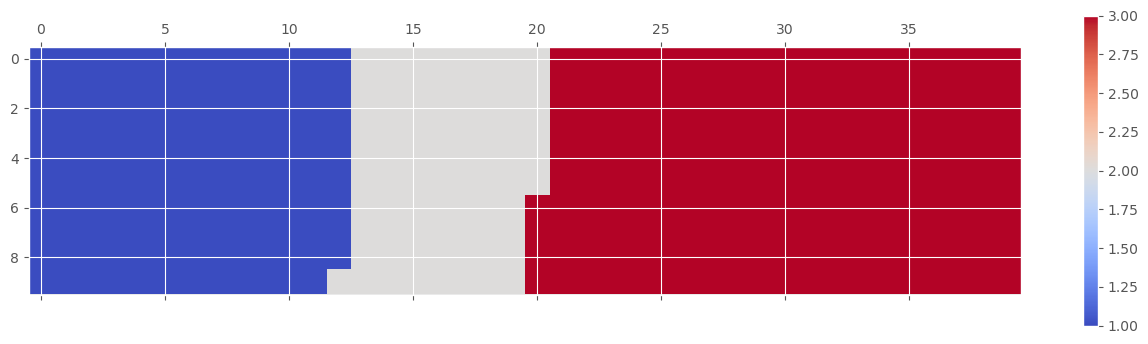

In [86]:
# instantiate a new figure object
fig = plt.figure()

# use matshow to display the waffle chart
colormap = plt.cm.coolwarm
plt.matshow(waffle_chart, cmap=colormap)
plt.colorbar()
plt.show()

**Step 6.** prettify the chart

<Figure size 640x480 with 0 Axes>

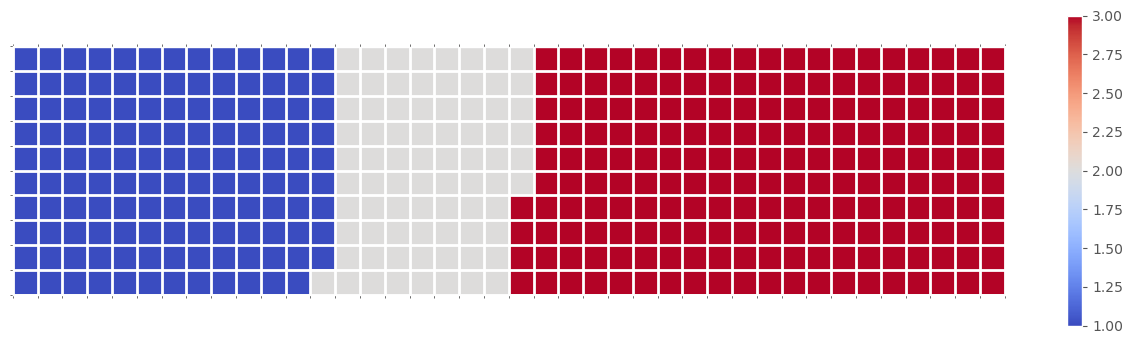

In [88]:
#instantiate a new figure object

fig = plt.figure()

#use matshow to display the waffle chart
colormap = plt.cm.coolwarm
plt.matshow(waffle_chart,cmap=colormap)
plt.colorbar()

#get the axis
ax = plt.gca()

#set minor ticks
ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
ax.set_yticks(np.arange(-.5, (height),1), minor=True)

#add gridlines based on minor ticks
ax.grid(which='minor',color='w', linestyle='-', linewidth=2)

plt.xticks([])
plt.yticks([])
plt.show([])

**Step 7.** create a legend and add it to the chart

C:\Users\redek\AppData\Local\Temp\ipykernel_10592\4086672569.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_values = values_cumsum[len(values_cumsum) - 1]
C:\Users\redek\AppData\Local\Temp\ipykernel_10592\4086672569.py:29: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_str = category +' (' + str(df_dsn['Total'][i]) + ')'
C:\Users\redek\AppData\Local\Temp\ipykernel_10592\4086672569.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use 

<Figure size 640x480 with 0 Axes>

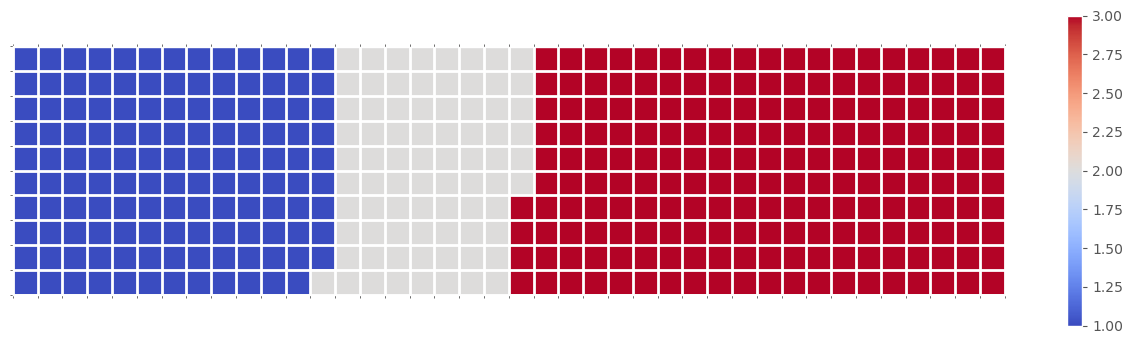

<Figure size 640x480 with 0 Axes>

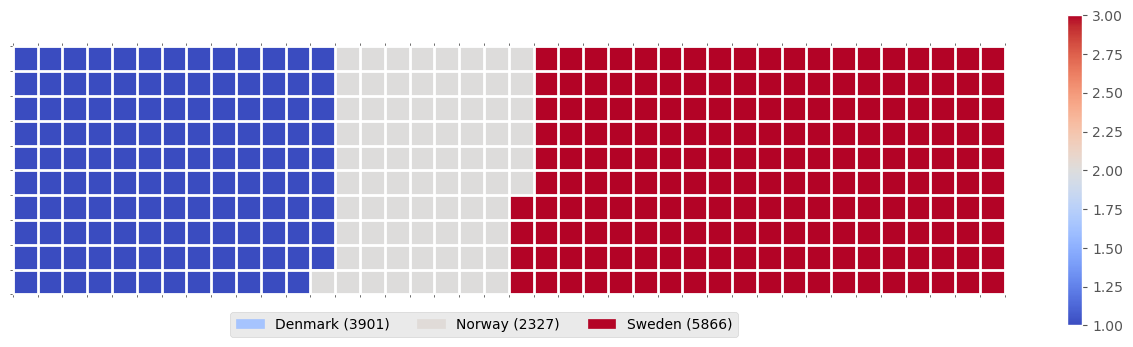

In [90]:
#instantiate a new figure object
fig = plt.figure()

#use matshow to display the waffle chart
colormap = plt.cm.coolwarm
plt.matshow(waffle_chart, cmap=colormap)
plt.colorbar()

#get the axis
ax = plt.gca()

#set minor ticks
ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
ax.set_yticks(np.arange(-.5, (height), 1), minor=True)

#add gridlines based on minor ticks
ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

plt.xticks([])
plt.yticks([])

#compute the cumulative sum of individual categories to match color shemes between chart and legend
values_cumsum=np.cumsum(df_dsn['Total'])
total_values = values_cumsum[len(values_cumsum) - 1]

#create legend
legend_handles = []
for i, category in enumerate(df_dsn.index.values):
    label_str = category +' (' + str(df_dsn['Total'][i]) + ')'
    color_val = colormap(float(values_cumsum[i])/total_values)
    legend_handles.append(mpatches.Patch(color=color_val,label=label_str))

#add legend to chart
plt.legend(handles=legend_handles,
           loc ='lower center',
           ncol=len(df_dsn.index.values),
           bbox_to_anchor=(0., -0.2, 0.95, .1)
          )
plt.show()

And there you go. A good looking `waffle` chart!<br><br>
Now it would be very inefficient to repeat these seven steps everry time we wish yo create a `waffle chart`. so let's combine all seven steps into one function called *create_waffle*. This function would take the following parameters as input<br>
> 1. **categories**: Unique categories or classes in dataframe
> 2. **values**: Values corresponding to categories or classes
> 3. **height**: Defined height of the waffle chart
> 4. **width**: Defined width of waffle chart
> 5. **colormap**: Colormap class
> 6. **value_sign**: In order to make our function more generalizable, we will add this parameter to address signs that could be associated with a value such as %, $, and so on. **value_sign** has a default value of empty string.

In [ ]:
def create_waffle_chart(categories,values,height,width,colormap,value_sign=''):

    #compute the proportion of each category with respect to the total
    total_values=sum(values)
    category_proportions = [(float(value)/total_values) for value in values]
    
    #compute the total number of tiles
    total_num_tiles = width*height #total number of tiles
    print('Total number of tiles is', total_num_tiles)
    
    tiles_per_category = [round(proportion*total_num_tiles) for proportion in category_proportions]

    #print out numbe of tiles for our `category`
    for i, tiles in enumerate(tiles_per_category):
        print(df_dsn.index.values[i] + ': ' +str(tiles))

    #initiate the waffle chart as an empty matrix
    waffle_chart = np.zeros((height,width))

    #define indices to loop through waffle chart
    category_index = 0
    tile_index = 0

    #populate the waffle chart
    for col in range(width):
        for row in range(height):
            tile_index +=1

            #if the number of tiles populated for the current category...
            #is equal to its corresponding allocated tiles...
            if tile_index > sum(tiles_per_category[0:category_index]):
                #...proceed to the next category
                category_index += 1

            #set the calss value to an integer, which increases with class
            waffle_chart[row, col] = category_index

    #instantiate a new figure object
    fig = plt.figure()

    #use `matshow` to display the waffle chart
    colormap = plt.cm.coolwarm
    plt.matshow(waffle_chart, cmap=colormap)
    plt.colorbar()

    #get the axis
    ax = plt.gca()

    #set minor ticks
    ax.set_xticks(np.arange(-.5, (width), 1), minor = True)
    ax.set_yticks(np.arange(-.5, (height), 1), minor=True)

    #add `gridlines` based on minor ticks
    ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

    plt.xticks([])
    plt.yticks([])

    #compute cumulative sum of individual categories to match color schemes between chart and legend
    values_cumsum = np.cumsum(values)
    total_values = values_cumsum[len(values_cumsum) -1]

    #create legend
    legend_handles = []
    for i, category in enumerate(categories):
        if value_sign == '%':
            label_str = category + ' (' + str(values[i]) + value_sign + ')'
        else:
            label_str = category + ' (' + value_sign + str(values[i]) + ')'

        color_val = colormap(float(values_cumsum[i])/total_values)
        legend_handles.append(mpatches.Patch(color=color_val, label = label_str))

    #add legend to chart
    plt.legend(
        handles = legend_handles,
        loc = 'lower center',
        ncol=len(categories),
        bbox_to_anchor = (0., -0.2, 0.95, .1)
    )
    plt.show()

now to create the `waffle` chart, all we have to do is call the function `create_waffle_chart`. Let's define the input parameters

In [98]:
width = 40 # width of chart
height = 10 # height of chart

categories = df_dsn.index.values # categories
values = df_dsn['Total'] # correponding values of categories

colormap = plt.cm.coolwarm # color map class

and now let's call our function to create a `waffle` chart

Total number of tiles is 400
Denmark: 129
Norway: 77
Sweden: 194


C:\Users\redek\AppData\Local\Temp\ipykernel_10592\2653586641.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_values = values_cumsum[len(values_cumsum) -1]
C:\Users\redek\AppData\Local\Temp\ipykernel_10592\2653586641.py:69: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_str = category + ' (' + value_sign + str(values[i]) + ')'
C:\Users\redek\AppData\Local\Temp\ipykernel_10592\2653586641.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, 

<Figure size 640x480 with 0 Axes>

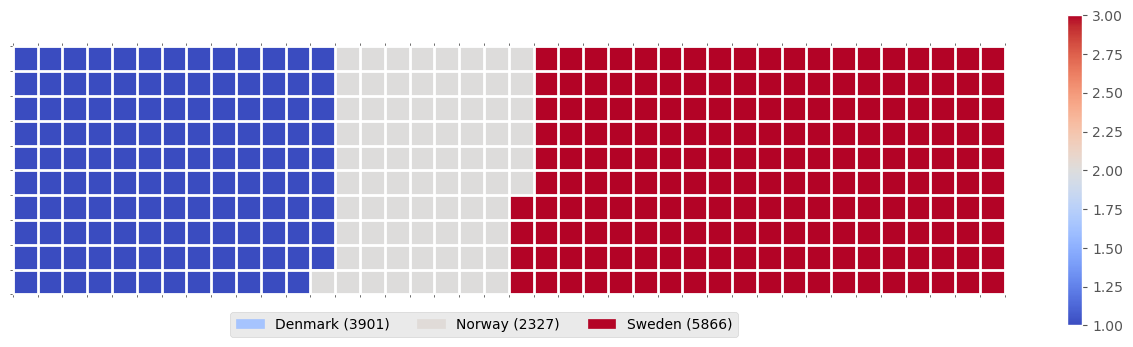

In [100]:
create_waffle_chart(categories, values, height, width, colormap)

There is a newew Python package called **pywaffle** that will create `waffle` charts. let's check it out

In [112]:
!pip install pywaffle

   ---------------------------------------- 0.0/25.6 MB ? eta -:--:--
   ------------- -------------------------- 8.7/25.6 MB 48.8 MB/s eta 0:00:01
   -------------------------------- ------- 21.0/25.6 MB 55.2 MB/s eta 0:00:01
   ---------------------------------------- 25.6/25.6 MB 52.4 MB/s eta 0:00:00


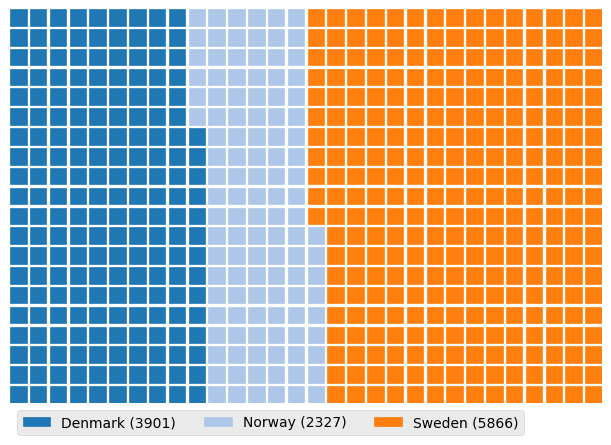

In [120]:
#import Waffle from pywaffle
from pywaffle import Waffle

#set up the waffle chart figure

fig = plt.figure(FigureClass = Waffle,
                 rows = 20, columns = 30, #pass the number of rows and columns for the waffle
                 values = df_dsn['Total'],
                 cmap_name = 'tab20',
                 legend = {'labels': [f"{k} ({v})" for k, v in zip(df_dsn.index.values,df_dsn.Total)],
                           'loc': 'lower left', 'bbox_to_anchor':(0,-0.1),'ncol':3}
                 #notice the use of list comprehension for creating labels
                 #from index and total of the `dataset`
                )
#display the waffle chart
plt.show()

**Question:** create a Waffle chart to display the proportions of China and India total immigration

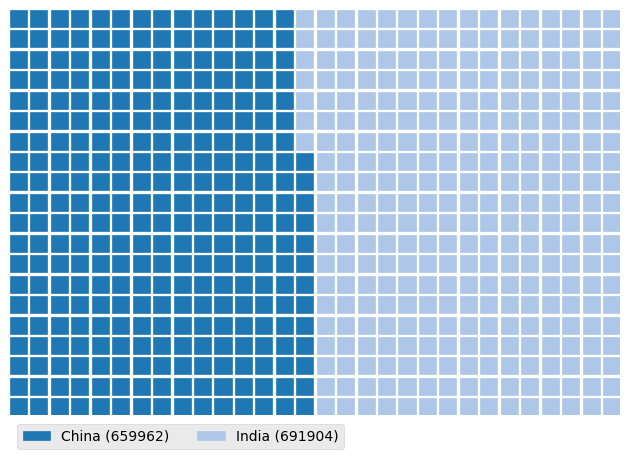

In [127]:
#Create a new dataframe for these 3 countries
df_ci = df_can.loc[['China', 'India']]

#import Waffle from pywaffle
from pywaffle import Waffle

#set up the waffle chart figure

fig = plt.figure(FigureClass = Waffle,
                 rows = 20, columns = 30, #pass the number of rows and columns for the waffle
                 values = df_ci['Total'],
                 cmap_name = 'tab20',
                 legend = {'labels': [f"{k} ({v})" for k, v in zip(df_ci.index.values,df_ci.Total)],
                           'loc': 'lower left', 'bbox_to_anchor':(0,-0.1),'ncol':3}
                 #notice the use of list comprehension for creating labels
                 #from index and total of the `dataset`
                )
#display the waffle chart
plt.show()

# Word Clouds

`word` clouds (also known as text clouds or tag clouds) work in a simple way: the more a specific word appears in a source of textual data (such as speech, blog post, or database), the bigger and bolder it appears in the word cloud

Luckily, a Python package already exists in Python to generate `word` clouds. The package, called `word_cloud`, developed by **Andreas Mueller**.
You can learn more about the package by following this [link](https://github.com/amueller/word_cloud/)

let's use this package to learn how to generate a word cloud for a given text document

Firsst let's install a package

In [131]:
#import package and its set of `stopwords`
from wordcloud import WordCloud, STOPWORDS

print('wordcloud imported!')

wordcloud imported!


\`word` clouds are commonly used to perform high-level analysis and visualization of text data.
Accordingly, let's digress from the immigration dataset and work with an example that involves analyzing text data. Let's try to analyze a short novel written by **Lewis Carrol** titled _Alice's Adventures in Wonderland__. Lat's go ahead and download a .txt file of the novel

In [135]:
import urllib

# open the file and read it into a variable, alice_novel
alice_novel = urllib.request.urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/alice_novel.txt').read().decode("utf-8")

next, let's use the stopwords that we imported from `word_cloud`. We use the function _set_ to remove any redundant stopwords

In [138]:
stopwords = set(STOPWORDS)

Create a word cloiud object and generate a word cloud. For simplicity, let's generate a word cloud using only the first 2000 words in the novel

In [141]:
#if you get attribute error while generating wordcloud,upgrade Pillow and numpy using below code
#%pip install --upgrade Pillow
#%pip install --upgrade numpy

In [145]:
#instantiate a word cloud object
alice_wc=WordCloud()

#generate the word cloud
alice_wc.generate(alice_novel)

now the word cloud is created, let's visualize it

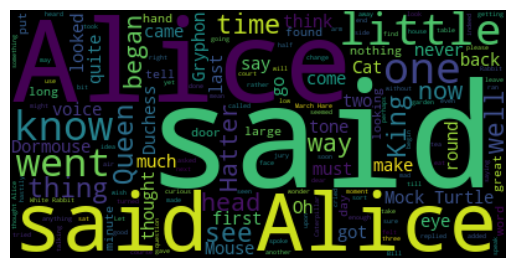

In [148]:
#display the word cloud
plt.imshow(alice_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Interesting! So in the first 2000 words in the nvel, the most common words are __Alice__, __said__, __little__, __Queen__, and so on. Leet's resize the cloud so that we can see the less frequent words  a little better.

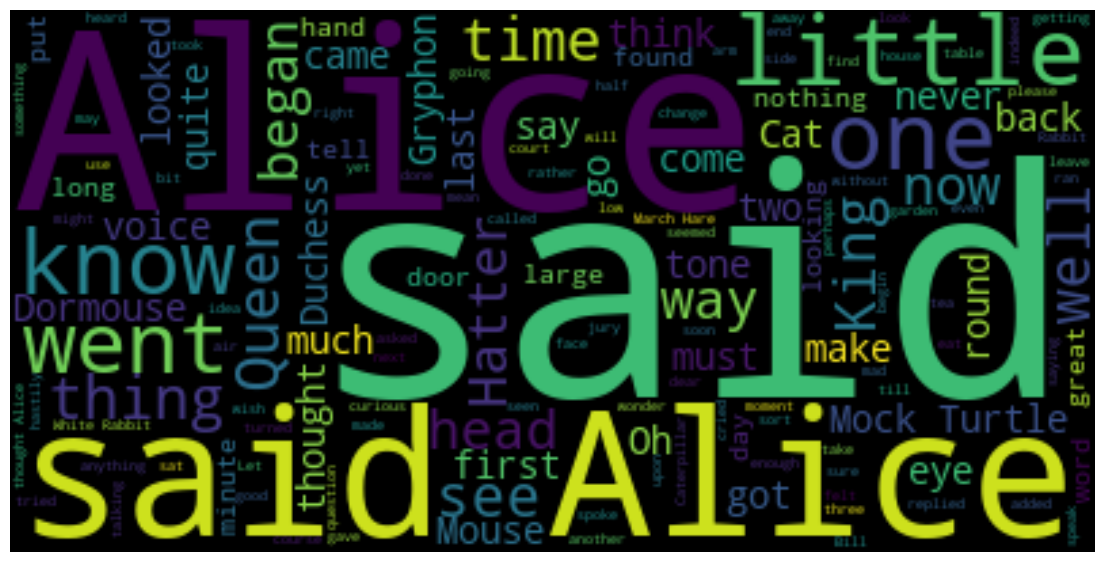

In [151]:
fig = plt.figure(figsize=(14,18))

#display the cloud
plt.imshow(alice_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Much better! However, __said__ isn't really an informative word. So let's add tour stopwords and re-generate the cloud

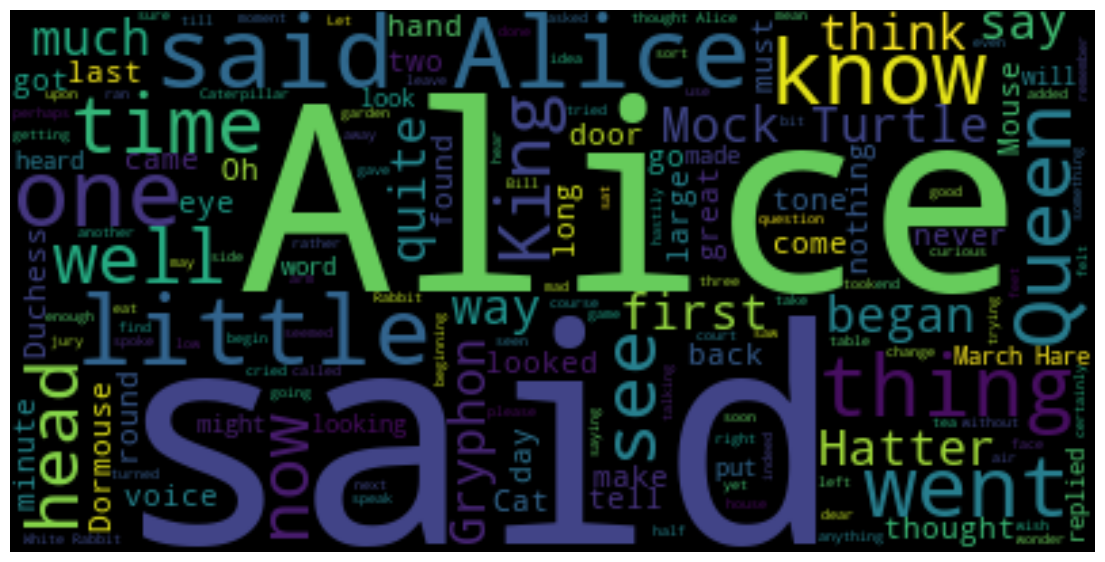

In [154]:
stopwords.add('said') #add the words said to `stopwords`

#re-generate the word cloud
alice_wc.generate(alice_novel)

#display the cloud
fig = plt.figure(figsize=(14,18))

plt.imshow(alice_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

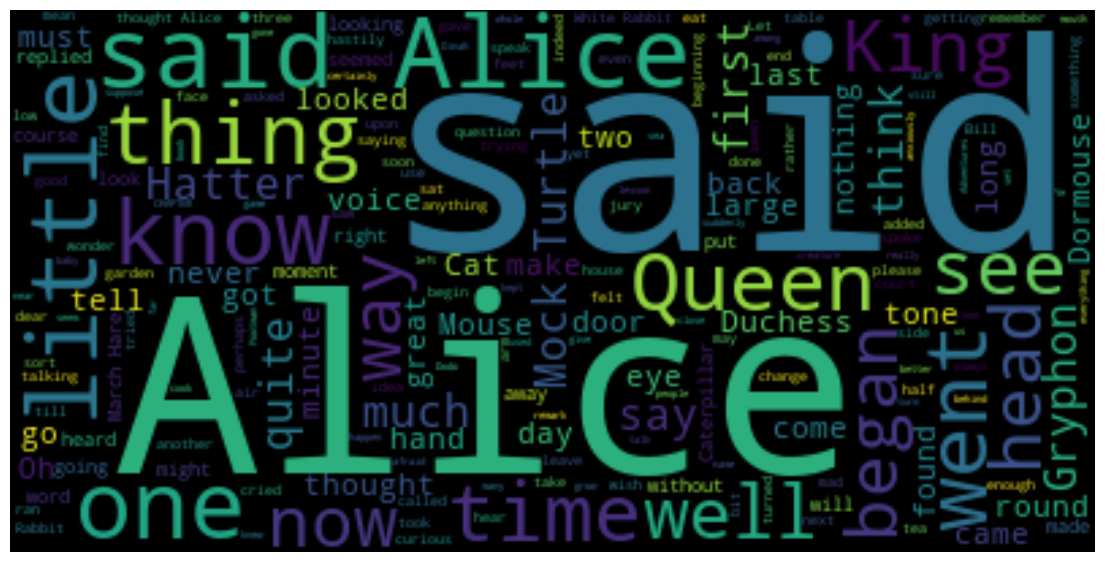

In [156]:
stopwords.add('said') # add the words said to `stopwords`

#re-generate the word cloud
alice_wc.generate(alice_novel)

#display the cloud
fig = plt.figure(figsize=(14,18))

plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()

This looks interesting! Another cool thing you can implement with the `word_cloud` package is superimposing the words onto a mask of any shape. Let's use a mask of Alice and her rabbit. We already created the mask for you, so let's go ahead and download it and call it _alice_mask.png_

In [161]:
#save mask to alice_massk
alice_mask = np.array(Image.open(urllib.request.urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/labs/Module%204/images/alice_mask.png')))

Let's take a look at how the mask looks like

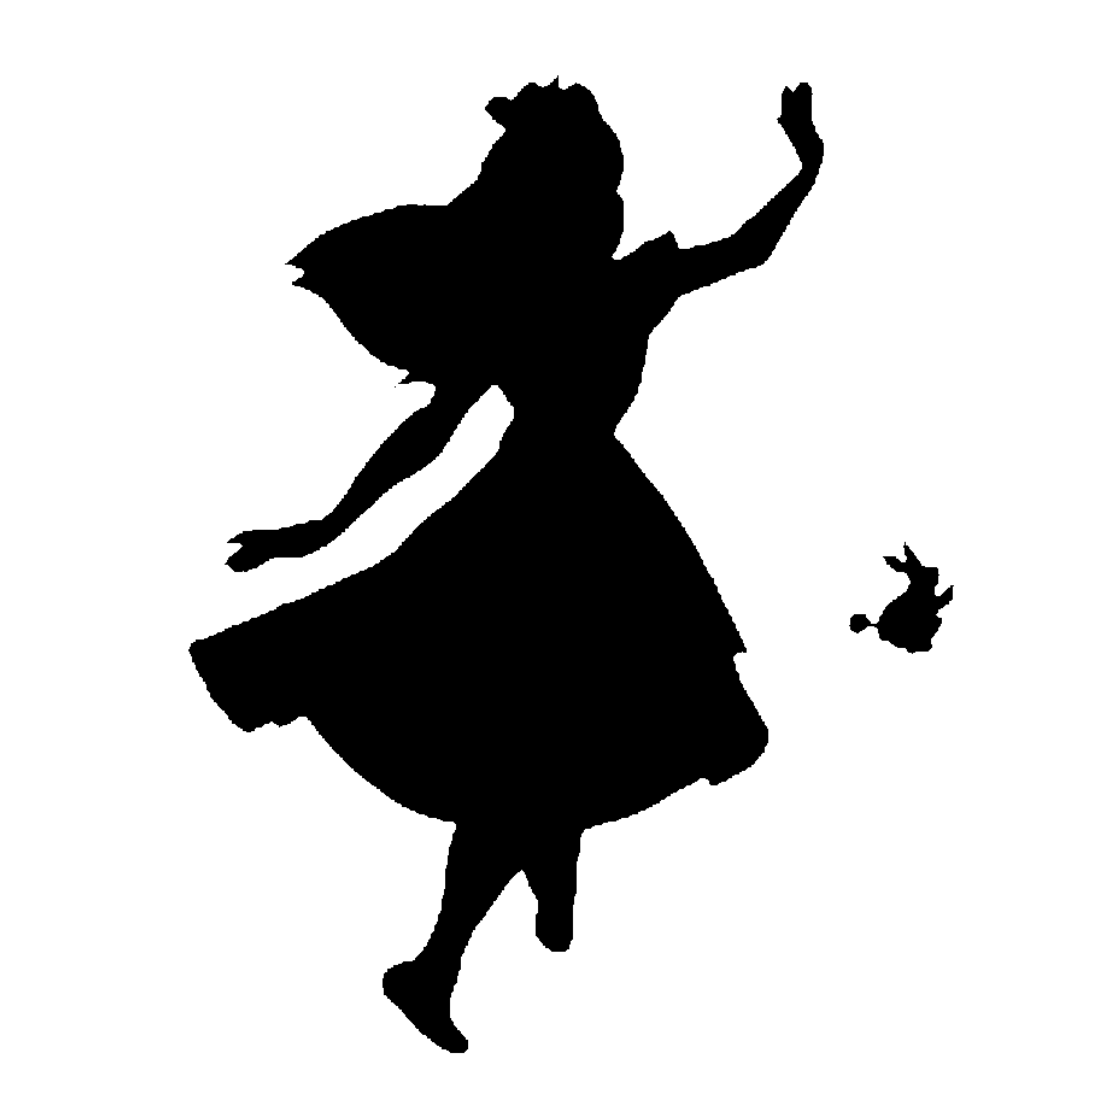

In [167]:
fig = plt.figure(figsize=(14,18))

plt.imshow(alice_mask, cmap=plt.cm.gray, interpolation='bilinear')
plt.axis('off')
plt.show()

shaping the `word` cloud according to the mask is straightforward using `word_cloud` package.
for simplicity, we will continue using the first 2000 words in the novel

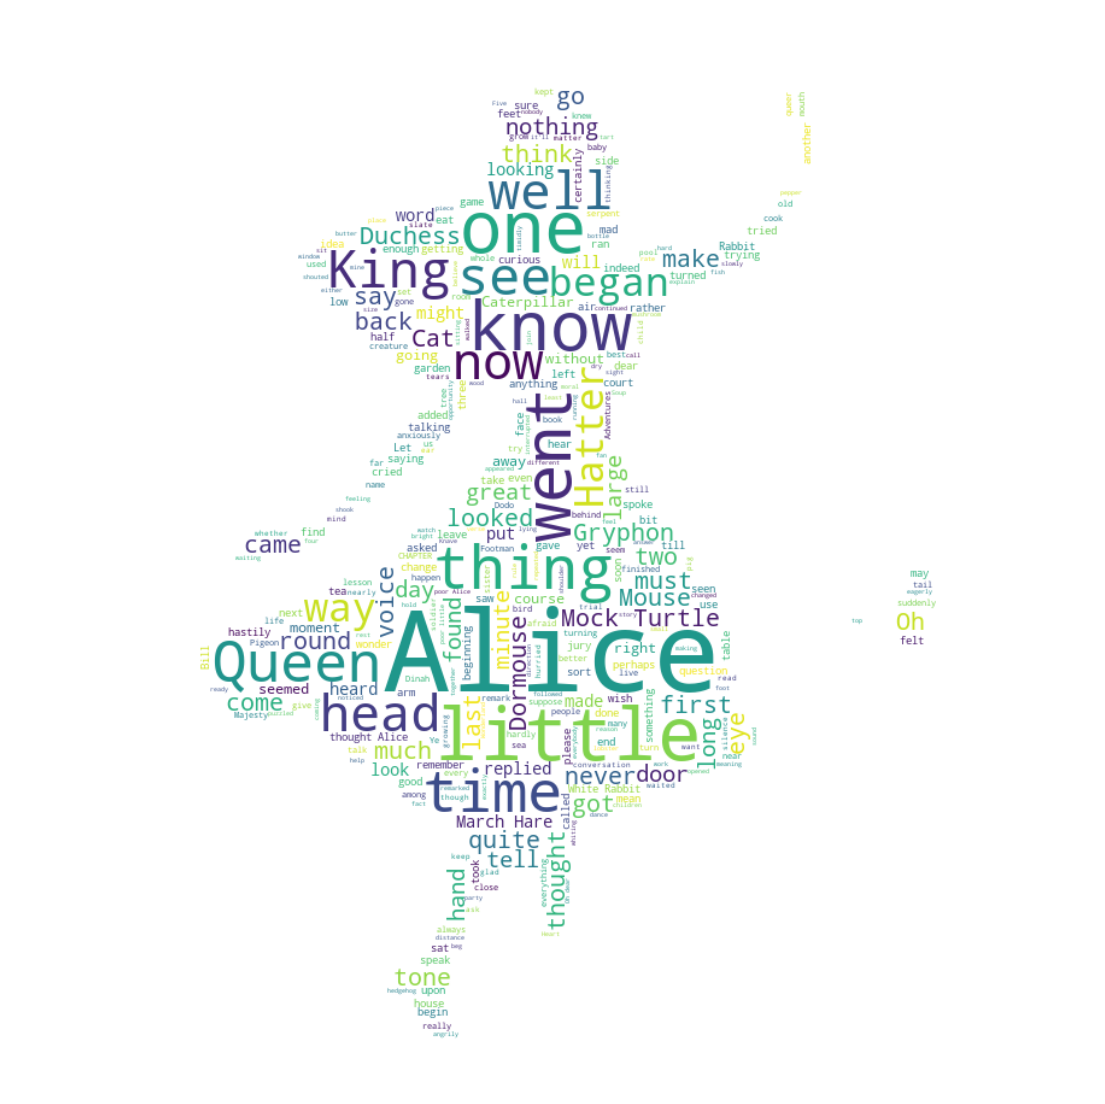

In [170]:
#instantiate a word cloud object
alice_wc = WordCloud(background_color='white', max_words=2000, mask=alice_mask, stopwords=stopwords)

#generate the word cloud
alice_wc.generate(alice_novel)

#display the word cloud
fig=plt.figure(figsize=(14,18))

plt.imshow(alice_wc, interpolation = 'bilinear')
plt.axis('off')
plt.show()

Dope! 

Unfortunately, our immigration data does not have any text data, but where there is a will there is a way. Let's generate sample text data from our immigration dataset, say text data of 90 words.

Let's recall how our data looks like

In [173]:
df_can.head()

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699
Algeria,Africa,Northern Africa,Developing regions,80,67,71,69,63,44,69,...,3626,4807,3623,4005,5393,4752,4325,3774,4331,69439
American Samoa,Oceania,Polynesia,Developing regions,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,6
Andorra,Europe,Southern Europe,Developed regions,0,0,0,0,0,0,2,...,0,1,1,0,0,0,0,1,1,15


And what the total immigration from 1980 to 2013?

In [178]:
total_immigration = df_can['Total'].sum()
total_immigration

6409153

using countries with single-word naames, let's duplicate each country's name based on how much they contribute to the total immigration

In [181]:
max_words = 90
word_string = ''
for country in df_can.index.values:
    #check if country's name is a single-word name
    if country.count(" ")==0:
        repeat_num_times = int(df_can.loc[country, 'Total']/total_immigration*max_words)
        word_string=word_string + ((country + ' ')*repeat_num_times)

#display the generated text
word_string

'China China China China China China China China China Colombia Egypt France Guyana Haiti India India India India India India India India India Jamaica Lebanon Morocco Pakistan Pakistan Pakistan Philippines Philippines Philippines Philippines Philippines Philippines Philippines Poland Portugal Romania '

We are not dealing with any stopwords here, so there is no need to pass them when creating the word cloud

In [185]:
#create the word cloud
wordcloud = WordCloud(background_color='white').generate(word_string)
print('word cloud created!')

word cloud created!


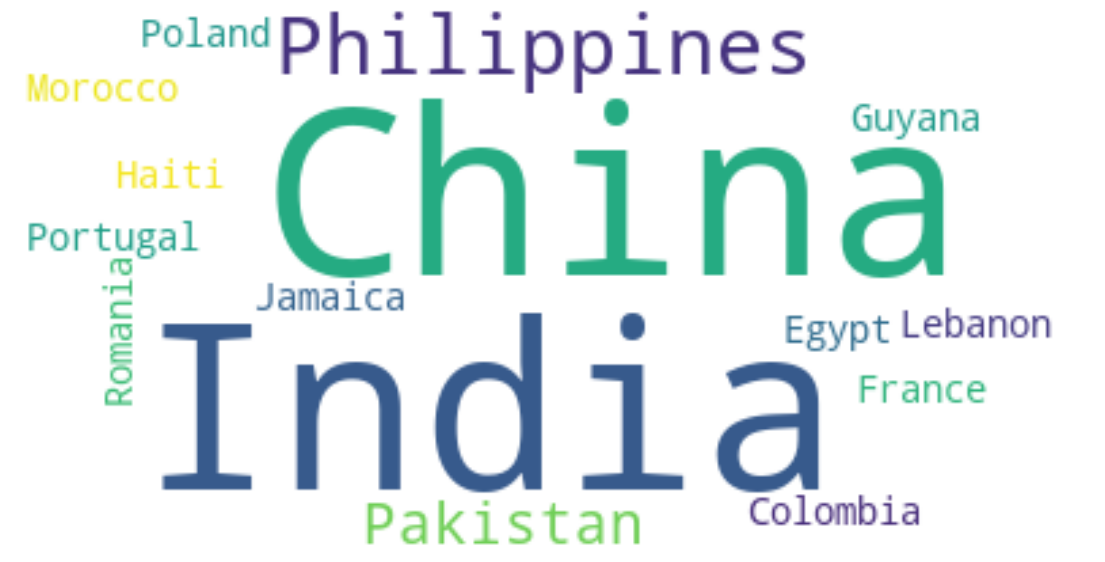

In [187]:
#display the cloud
plt.figure(figsize=(14,18))

plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis('off')
plt.show()

According to the above word cloud, it looks like the majority of the people who immigrated came from one of 15 countries that are displayed by the word cloud. One cool visual that you could build, is perhaps using the map of canada and a mask and superimposing the word cloud on top of the map of Canada. That would look interesting as a visual

# Plotting with Seaborn <a id="5"></a>

> Seaborn is a Python visualizaiton library based on matplotlib.. It provides a high-level interface for drawing attractive statistical graphics. You can learn more about *seaborn* by following this [link](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDV0101ENSkillsNetwork20297740-2021-01-01) and more about *seaborn* regression plots by following this [link](http://seaborn.pydata.org/generated/seaborn.regplot.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkDV0101ENSkillsNetwork20297740-2021-01-01).


In lab _Pie Charts_, _Box Plots_,  _Scatter Plots_, and _Bubble Plots_, we learned how to create a scatter plot and then fit a regression line. It took ~20 lines of code to create the scatter plot along with the regression fit. In this final section, we will explore _seaborn_ and see how efficient it is to create regression lines and fits using this library!

### Categorical Plots
In our data 'df_can', let's find out how many continents are mentioned

In [196]:
df_can['Continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania',
       'Latin America and the Caribbean', 'Northern America'],
      dtype=object)

## countplot
__a count plot can be though of as a histogram across categorical, instead of quantitative, variable.__ Let's find the count of Continents in the data 'da_can' using countplot on 'Continent'

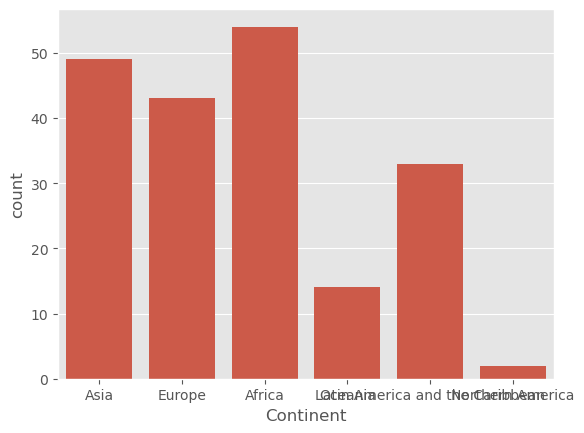

In [263]:
sns.countplot(x='Continent', data=df_can)
plt.show()

The label on the x-axis doesn't look as expected.
Let's try to replace the 'Latin America and the Caribbean' with the"L-America", 'Northern America', with "N-America".
and change the figure size and then display the plot again

In [253]:
df_can1 = df_can.replace('Latin America and the Caribbean', 'L-America')
df_can1 = df_can1.replace('Northerrn America', 'N-America')

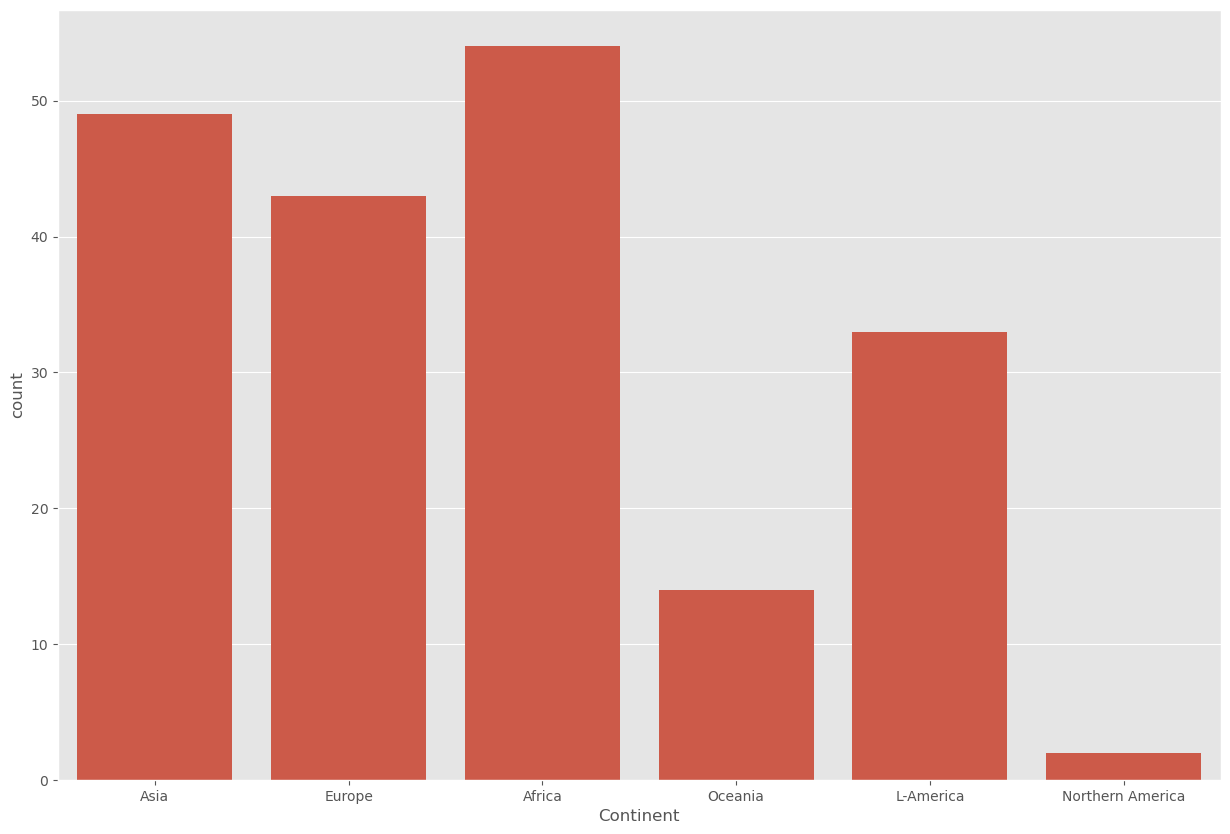

In [255]:
plt.figure(figsize=(15,10))
sns.countplot(x='Continent', data=df_can1)
plt.show()

In [216]:
df_can1['Continent'].unique()

array(['Asia', 'Europe', 'Africa', 'Oceania', 'L-America',
       'Northern America'], dtype=object)

Much better

## Barplot

__This plot will perform the Groupby on a categorical variable and plot aggregated values, with confidence intervals.__
<br>Let's plot the total immigrants Continent-wise

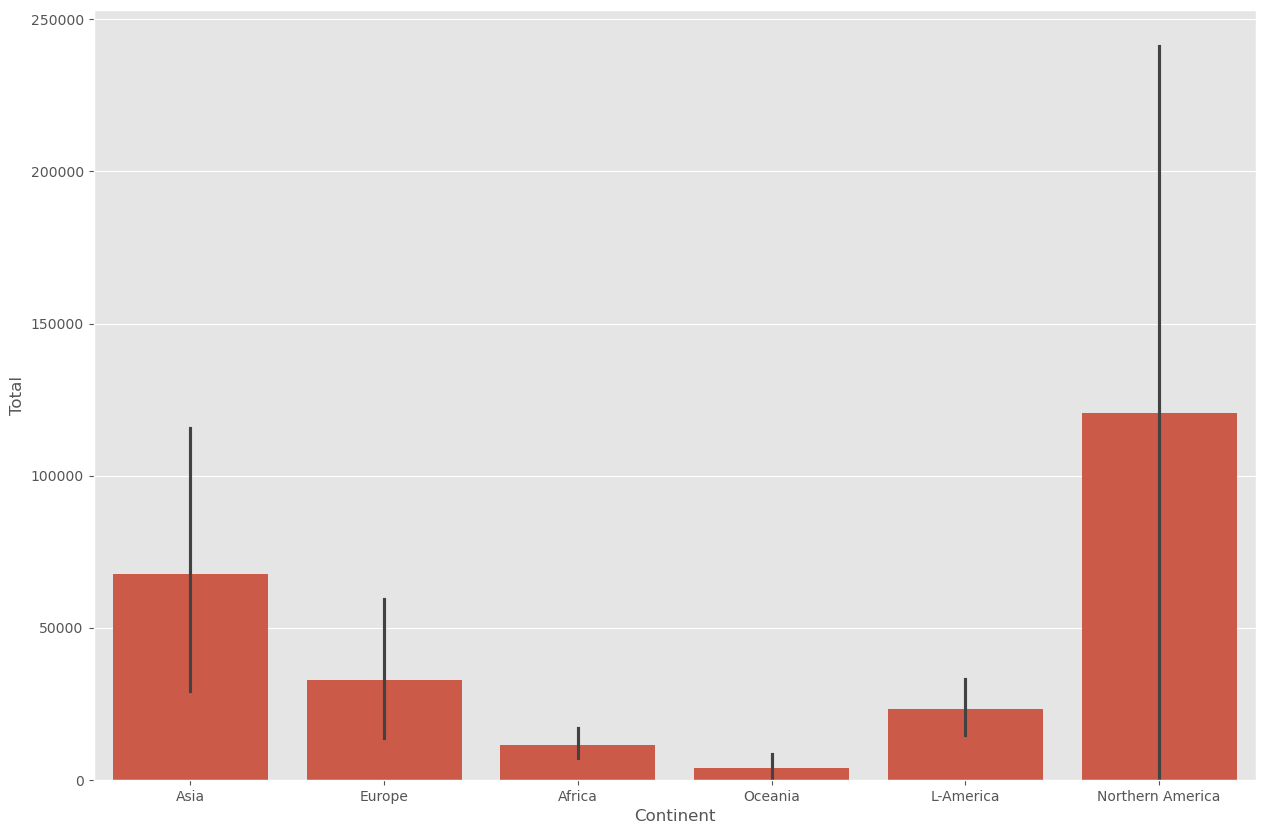

In [257]:
plt.figure(figsize=(15,10))
sns.barplot(x='Continent', y='Total', data=df_can1)
plt.show()

You can verify the values by performing the groupby on the Total and Continent for mean()

In [265]:
df_can2 = df_can1.groupby('Continent')['Total'].mean()
df_can2

Continent
Africa               11462.000000
Asia                 67710.081633
Europe               32812.720930
L-America            23186.303030
Northern America    120571.000000
Oceania               3941.000000
Name: Total, dtype: float64

Create a new dataframe that stores that total number of landed immigratns to Canada per year from 1980 to 2013

## Regression Plot

with  _seaborn_, generating a regression plot is as simple as calling the **regplot** function

In [273]:
years = list(map(str, range(1980,2013)))
#we can use the sum() method to get the total population per year
df_tot = pd.DataFrame(df_can[years].sum(axis = 0))

#change the years to type float (useful for regression later on)
df_tot.index =map(float, df_tot.index)

#reset the index to put it back in as a column in the df_tot dataframe
df_tot.reset_index(inplace=True)

#rename the columns
df_tot.columns = ['year', 'total']

#view the final dataframe
df_tot.head()

,year,total
0,1980.0,99137
1,1981.0,110563
2,1982.0,104271
3,1983.0,75550
4,1984.0,73417


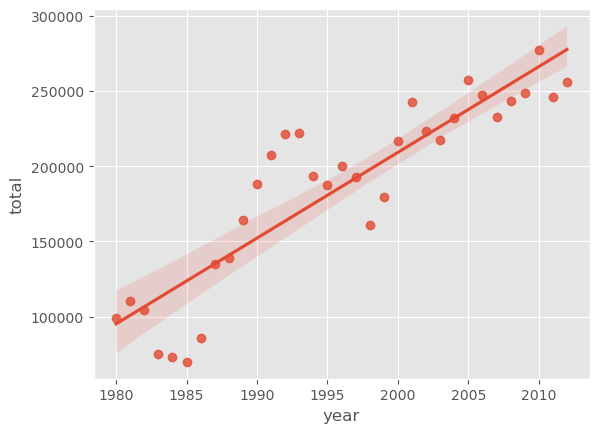

In [284]:
#seaborn is already imported at the start of this lab
sns.regplot(x='year', y='total', data=df_tot)
#plt.show()
plt.show()

This is not magic, it's _seaborn_! You can also customize the color of the scatter plot and regression line. Let's change the color to green

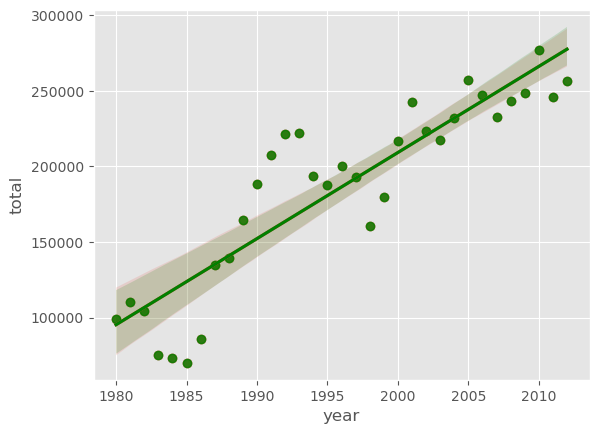

In [282]:
sns.regplot(x='year', y='total', data=df_tot, color='green')
plt.show()

you can always customize the marker shape, so instead of circular markers, let's use `+`

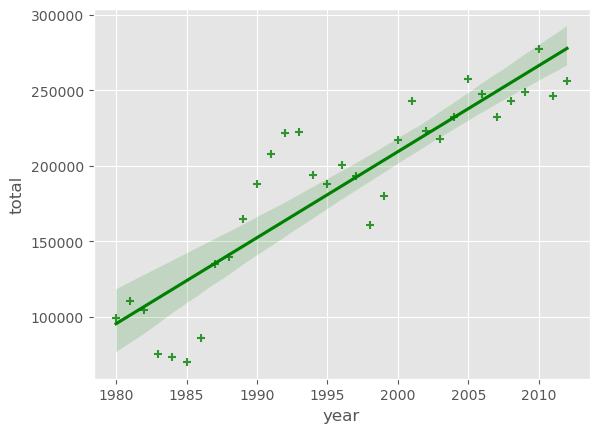

In [287]:
ax = sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+')
plt.show()

and let's increase the size of markers so they match the new size of the figure, and add a title and x- and y- labels

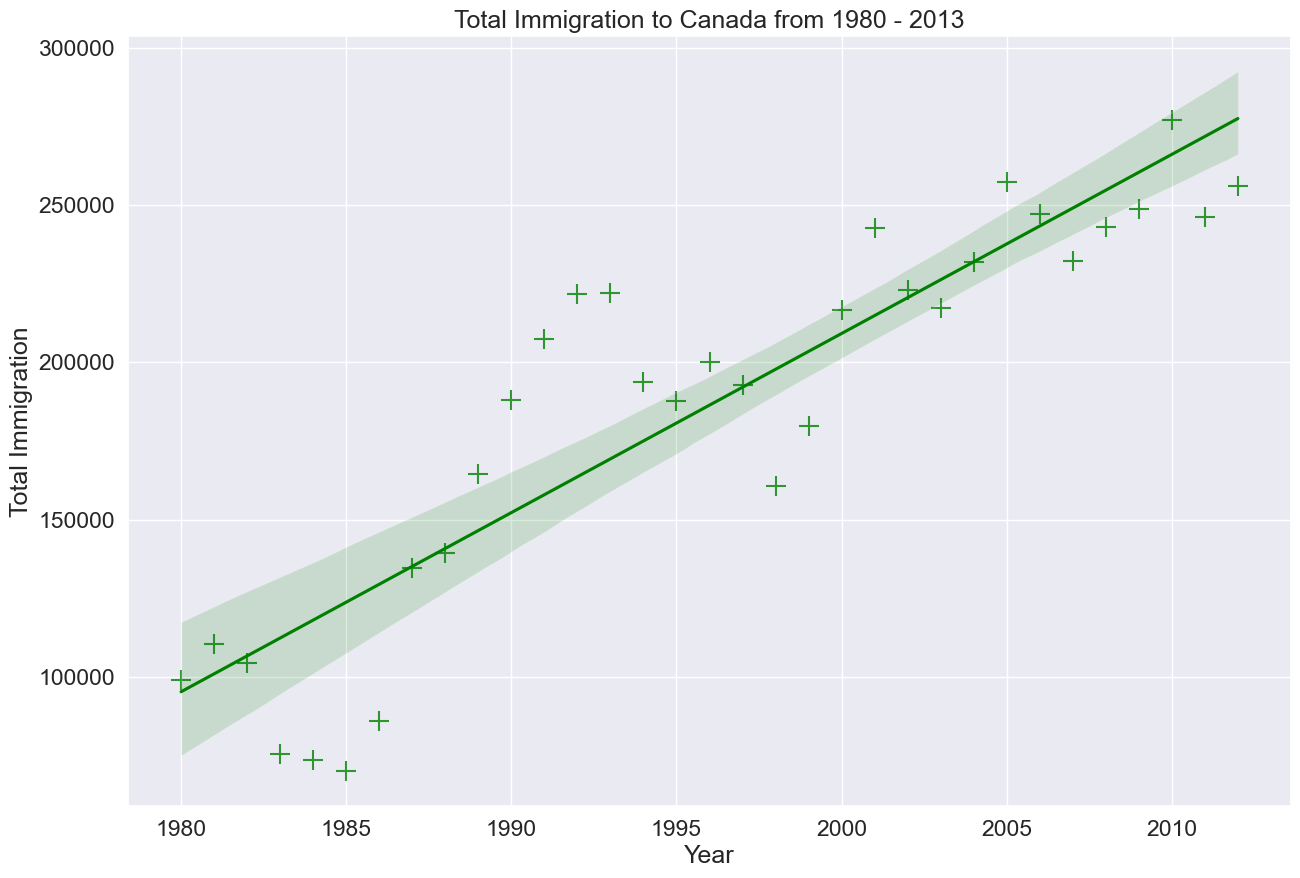

In [295]:
plt.figure(figsize=(15,10))

sns.set(font_scale=1.5)

ax = sns.regplot(x='year', y='total', data = df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration') #add x and y labels
ax.set_title('Total Immigration to Canada from 1980 - 2013') #add title
plt.show()

There you have it. A complete scatter plot with a regression fit with 5 lines of code only. Isn't this really amazing?

If you are not a big fan of the purple background, you can easily change the style to a white plain background

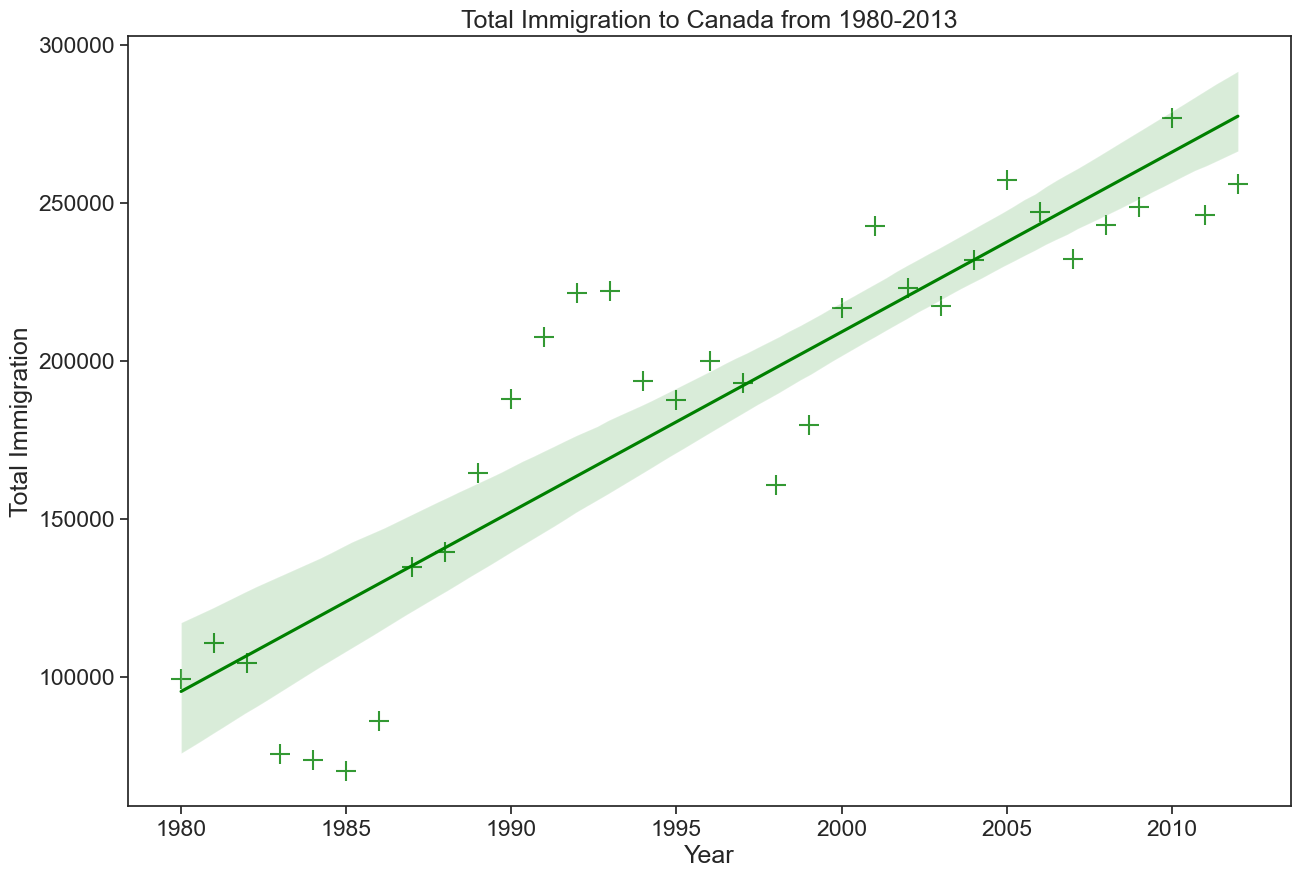

In [302]:
plt.figure(figsize=(15,10))
sns.set(font_scale=1.5)
sns.set_style('ticks') # change background to white background

ax = sns.regplot(x='year', y='total', data=df_tot, color = 'green', marker = '+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980-2013')
plt.show()

Or to a white background with gridlines

<Figure size 1500x1000 with 0 Axes>

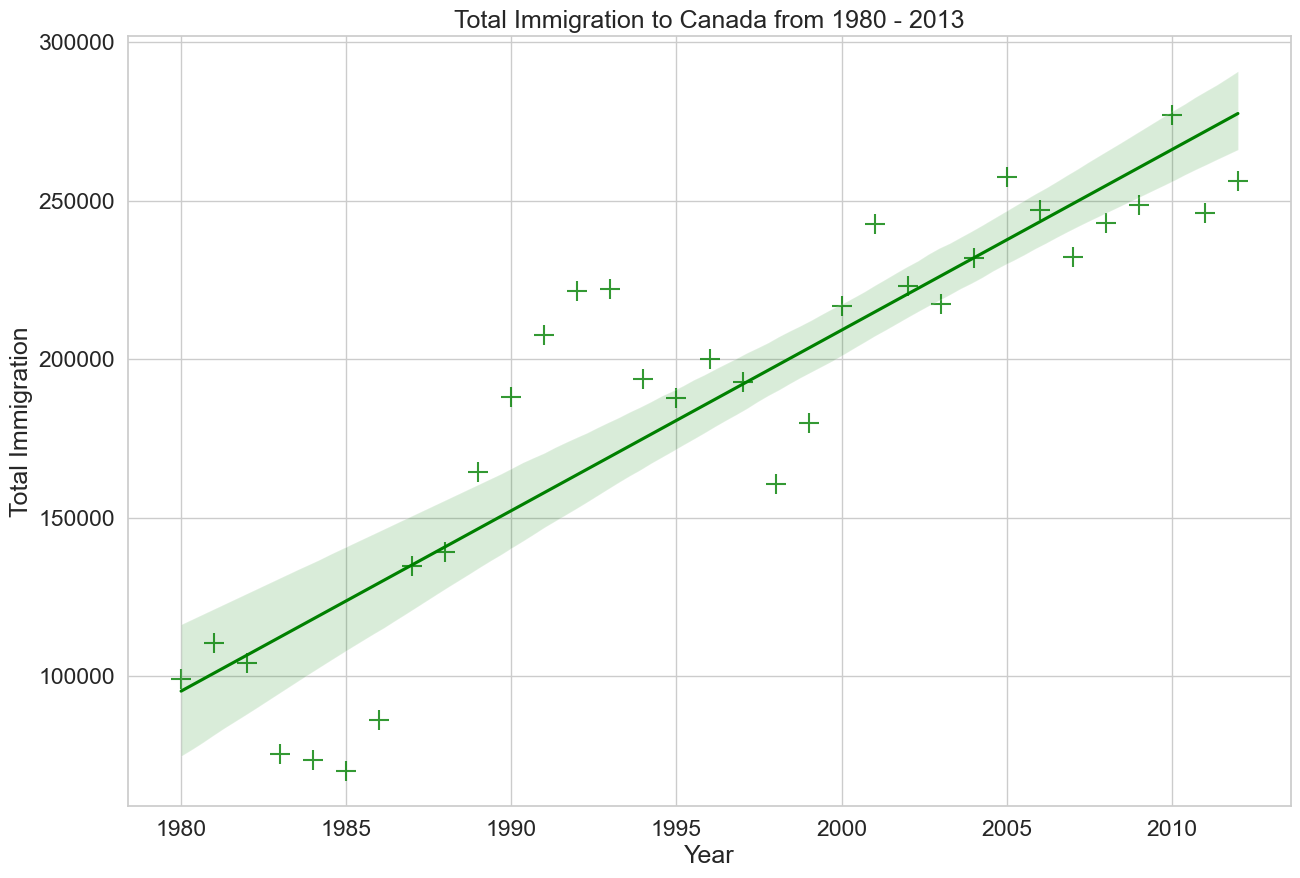

In [307]:
plt.figure(figsize=(15,10))

sns.set(font_scale=1.5)
sns.set_style('whitegrid')

ax=sns.regplot(x='year', y='total', data=df_tot, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

__Question:__ Use seaborn to create a scatter plot with a regression line to visualize the total immigration from Denmakr, Sweden, and Norway to Canada from 1980 to 2013

In [317]:
#Create a new dataframe for these 3 countries
df_dsn = df_can.loc[['Denmark', 'Norway', 'Sweden']]

df_dsn

,Continent,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Country,,,,,,,,,,,,,,,,,,,,,
Denmark,Europe,Northern Europe,Developed regions,272,293,299,106,93,73,93,...,62,101,97,108,81,92,93,94,81,3901
Norway,Europe,Northern Europe,Developed regions,116,77,106,51,31,54,56,...,57,53,73,66,75,46,49,53,59,2327
Sweden,Europe,Northern Europe,Developed regions,281,308,222,176,128,158,187,...,205,139,193,165,167,159,134,140,140,5866


In [319]:
years1 = list(map(str, range(1980,2013)))
#we can use the sum() method to get the total population per year
df_tot1 = pd.DataFrame(df_dsn[years].sum(axis = 0))

#change the years to type float (useful for regression later on)
df_tot1.index =map(float, df_tot1.index)

#reset the index to put it back in as a column in the df_tot dataframe
df_tot1.reset_index(inplace=True)

#rename the columns
df_tot1.columns = ['year', 'total']

#view the final dataframe
df_tot1.head()

,year,total
0,1980.0,669
1,1981.0,678
2,1982.0,627
3,1983.0,333
4,1984.0,252


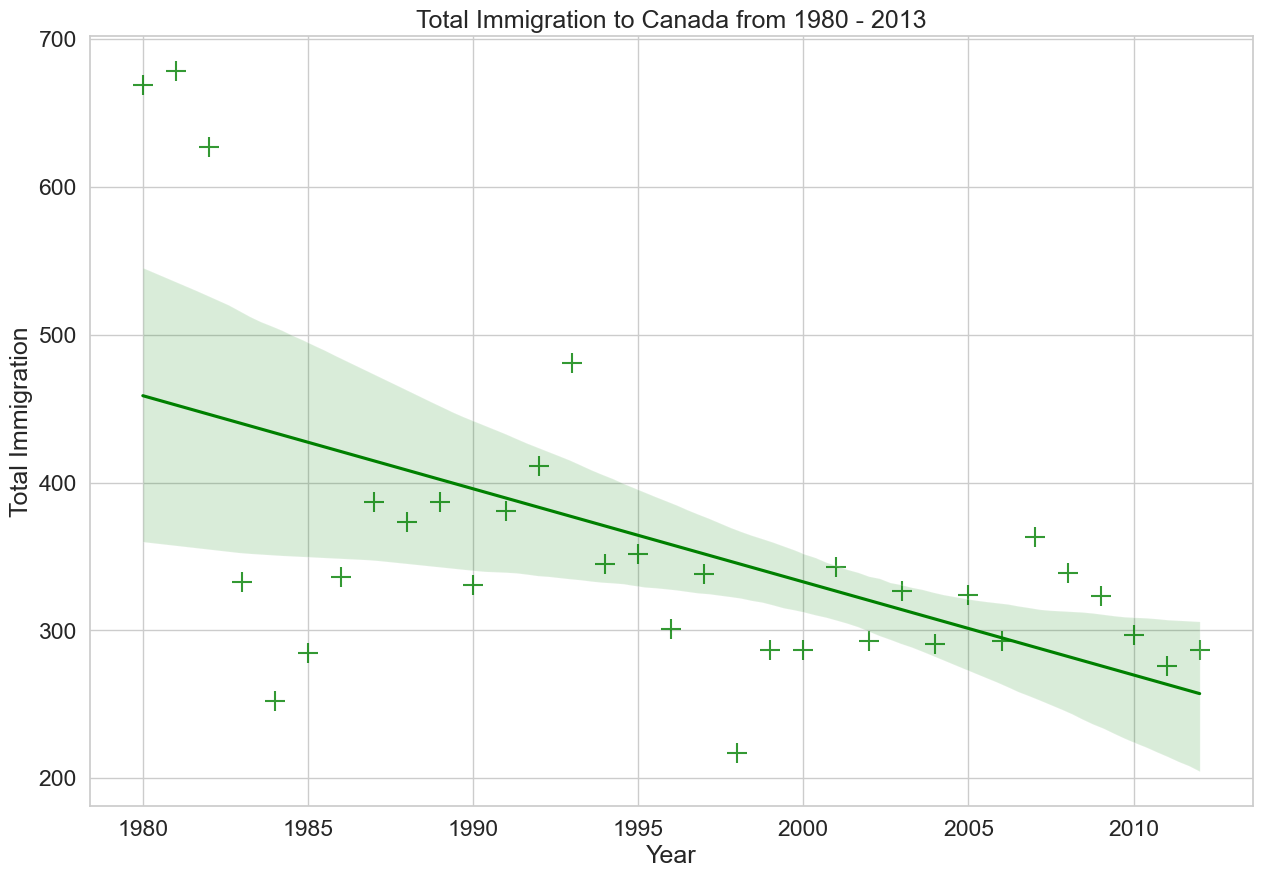

In [321]:
plt.figure(figsize=(15,10))

sns.set(font_scale=1.5)
sns.set_style('whitegrid')

ax=sns.regplot(x='year', y='total', data=df_tot1, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigration to Canada from 1980 - 2013')
plt.show()

### Below is the code example from the Hands-on Lab

In [330]:
# create df_countries dataframe
df_countries = df_can.loc[['Denmark', 'Norway', 'Sweden'], years].transpose()

# create df_total by summing across three countries for each year
df_total = pd.DataFrame(df_countries.sum(axis=1))

# reset index in place
df_total.reset_index(inplace=True)

# rename columns
df_total.columns = ['year', 'total']

# change column year from string to int to create scatter plot
df_total['year'] = df_total['year'].astype(int)

# define figure size
plt.figure(figsize=(15, 10))

# define background style and font size
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

# generate plot and add title and axes labels
ax = sns.regplot(x='year', y='total', data=df_total, color='green', marker='+', scatter_kws={'s': 200})
ax.set(xlabel='Year', ylabel='Total Immigration')
ax.set_title('Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

Text(0.5, 1.0, 'Total Immigrationn from Denmark, Sweden, and Norway to Canada from 1980 - 2013')

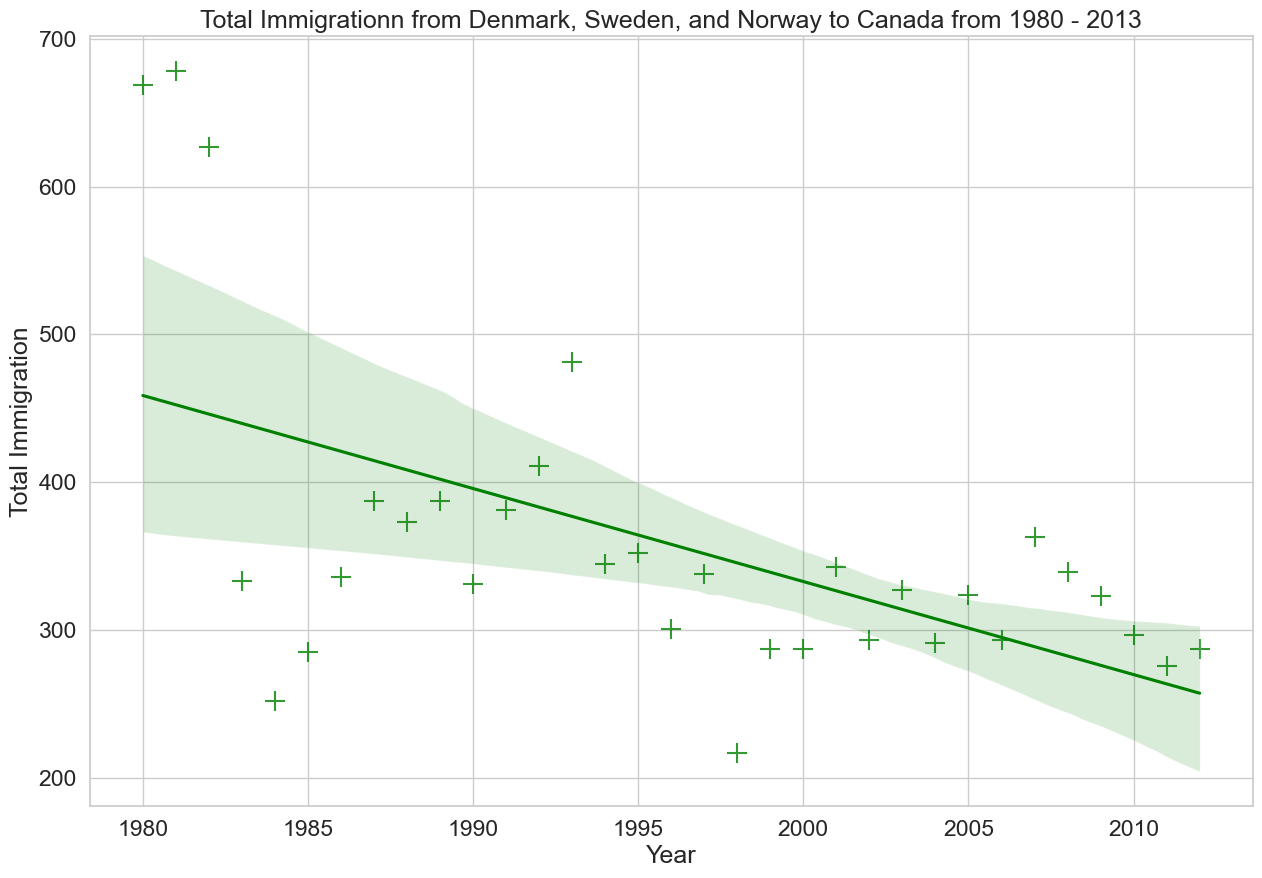

In [327]:
plt.show()